# CS 503 Foundation Models: Part 2 - nanoMaskGIT

#### Goals:

The goal of this second part is to familiarize yourself with the following topics:
- Bi-directional attention
- Encoder-only Transformer (e.g. BERT, MaskGIT, ...) models
- Basic masking schemes
- Masked modelling on text and images
- Masked inference

This notebook should give you a solid foundation of working with masked image models.
If you want to know more about these topics, please see some of the reading material in the lectures and at the bottom of this notebook, and feel free to ask the TAs.


#### Instructions:

- Your task is to fill in the missing code in the acompagning codebase (highlighted by `???`), run the training loops and evaluate the trained models with this notebook.
- Submit the notebook with all cells executed, as well as `nanofm/models/maskgit.py`.
- The notebooks are individual homework.

# 1. Setup

Please follow the instructions in the [README.md](../README.md) file to set up the environment.

### 1.1 Imports

In [1]:
# Switch path to root of project
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"
current_folder = globals()['_dh'][0]
os.chdir(os.path.dirname(os.path.abspath(current_folder)))

%load_ext autoreload
%autoreload 2

In [2]:
import re
import torch
from einops import rearrange
from transformers import AutoTokenizer
from tokenizers.processors import TemplateProcessing

import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import ImageGrid

from nanofm.utils.checkpoint import load_model_from_safetensors
from nanofm.data.vision.tokenized_mnist import create_tokenized_mnist_dataloader, detokenize_MNIST

os.environ["TOKENIZERS_PARALLELISM"] = "false"

# The flag below controls whether to allow TF32 on matmul. This flag defaults to False in PyTorch 1.12 and later.
torch.backends.cuda.matmul.allow_tf32 = True
# The flag below controls whether to allow TF32 on cuDNN. This flag defaults to True.
torch.backends.cudnn.allow_tf32 = True

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_grad_enabled(False)

/home/margeat/miniconda3/envs/nanofm/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch.autograd.grad_mode.set_grad_enabled(mode=False)

---

## 2 Training nanoMaskGIT on MNIST for image generation

In this exercise, we will implement a simplified masked generative model, similar to [MaskGIT](https://masked-generative-image-transformer.github.io/). 
As with our nanoGPT implementation, we will train it on MNIST for image generation, but will also later explore using it for text generation on TinyStories!

#### Masked modeling - Training objective

In contrast to autoregressive models that are trained to predict the next token given the context so far, masked generative models like MaskGIT are trained to predict any (masked-out) token given any other (non-masked) subset of tokens.
Consider the following example: 

**Original Sentence:**  
```
"The quick brown fox jumps over the lazy dog."
```

**Masked Training Example (cloze):**  
```
"The quick [MASK] fox jumps over the [MASK] dog."
```

**Goal:**  
The model must predict:
- `[MASK]` → "brown"
- `[MASK]` → "lazy"

By repeatedly training the model to predict these randomly masked tokens across a large dataset, MaskGIT learns how tokens fit contextually within sequences.


#### Masked modeling - Inference


By training a model with randomized masking ratios, we are able to use it to progressively "unmask" a fully masked initial sequence.
At inference, the model starts with all tokens masked and progressively unmasks tokens in multiple steps. Let's show an inference example generating two (`k=2`) tokens at a time.

**Initial Masked Sequence:**  
```
"[MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK]"
```

**Step-by-step Generation (k=2 tokens at a time):**  

- **Step 1:**  
```
"The [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] [MASK] dog."
```

- **Step 2:** (unmask next 2 most confident tokens)  
```
"The quick [MASK] [MASK] [MASK] [MASK] [MASK] lazy dog."
```

- **Step 3:** (unmask next 2 tokens)  
```
"The quick [MASK] fox [MASK] [MASK] [MASK] lazy dog."
```

- **Step 4:** (unmask next 2 tokens)  
```
"The quick brown fox jumps [MASK] the lazy dog."
```

- **Step 5 (Final):** (all tokens unmasked)  
```
"The quick brown fox jumps over the lazy dog."
```

At each inference step, MaskGIT predicts all masked-out tokens simultaneously (in parallel), and, based on the predicted probabilites, selects the `k` (here `k=2`) most likely tokens. 
After deciding on which tokens to use, we sample a token index from the predicted probability distribution for each token, and add the tokens to the sequence. 
This, now slightly less masked, sequence is then used as the input for the next round, where again, the `k=2` most confident tokens are chosen of the remaining masked targets.

A crucial difference of masked models to next-token prediction is that at each inference step we can freely choose the number of tokens `k` to simultaneously decode. 
Depending on the choice of `k`, this can speed up inference significantly, at little cost to generation performance. 
For example, see the comparison between raster-scan autoregressive, and masked generation below.
Each frame of the gif is one generation step. Autoregressive generation predicts each token one-by-one, while masked models may predict them in parallel.

![adsf](https://masked-generative-image-transformer.github.io/imgs/sampling.gif)

### 2.1 Overview and tasks

To implement nanoMaskGIT, we ask you to complete the subsections below by directly filling in the missing lines in the code base.

#### 2.1.1 Initialize nanoMaskGIT (5 points)

We will reuse the exact same Transformer layers and trunk built last week for the nanoGPT model, but this time we will use it to assemble a MaskGIT-like model in `nanofm.models.maskgit.MaskGIT`.
It consists of a few operations executed in series. Initialize the following modules in the constructor:
1. The discrete input tokens are embedded with an `nn.Embedding` layer. Initialize `self.input_embedding` accordingly, taking into account the vocabulary size.
2. On top of that, we add learnable positional embeddings. Initialize `self.positional_embedding` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`max_seq_len`, `dim`).
3. To indicate masked-out tokens and provide placeholders to write the targets, initialize `self.mask_token` as an `nn.Parameter` containing a randomly initialized Tensor of shape (`dim`).
4. This then gets passed to a Transformer trunk. Initialize `self.trunk` with the trunk you implemented last week.
5. Finally we project the trunk output through a LayerNorm and output projection that maps the elements from the Transformer dimension to the vocabulary size (as a one-hot vector per token). Initialize `self.out_norm` and `self.to_logits`. The bias term for `self.to_logits` should always be set to False.

#### 2.1.2 Implement the forward function and loss (10 points)

Next, let's implement the `forward_model` function:
1. Pass the input tokens through the embedding. 
2. Given the `mask`, replace these embeddings by the learned `self.mask_token`, wherever `mask == True`.
3. Add the positional embedding, pass it through the Transformer trunk, output normalization, and output projection.
4. When calling the Transformer trunk, no attention mask needs to be specified. This model performs full self-attention between all masked and non-masked tokens.

Finally, we need to compute the cross-entropy loss between the logits and the ground-truth targets. Please complete the `compute_ce_loss` function accordingly, and take into account the ignore_index token. We do not want to compute a loss on non-masked tokens that we pass as input; we only compute it on masked-out tokens that we predict.

#### 2.1.3 Implement random masking (15 points)

As used in the `forward` function, during training we want to randomize the `mask` you just applied to the inputs. 
For that, please complete the `generate_random_mask` function that should return a random mask where True = masked-out and False = not masked.
Each sample in the batch should randomly mask out between 1 and L tokens, where L is the sequence length. 
When L tokens are masked-out, it means there is no input and all tokens are predicted.
When only 1 token is masked-out, it means that all but one token are given as input, and only one is predicted. 
You should be able to see why we have to have at least one token masked.

The returned mask tensor should be of type `torch.BoolTensor`, moved to the same device (GPU) as `seq`, and be of shape (B, L).
Note that both the number of mask tokens, as well as the placement of the masks should be sampled completely uniformly at random, for every sample in the batch individually.
That means you should not apply and broadcast the same mask to the entire batch.

#### 2.1.4 MaskGIT schedule and generation function (20 points)

Now let's implement the generation function. We do that in two steps:

First, let's implement a so-called generation schedule in `get_maskgit_schedule`. 
Its task is to give us a list of number of tokens to unmask at every prediction step. 
It's quite common to make this a cosine schedule, i.e. where the tokens are unmasked slowly at the beginning, then in the middle many tokens are predicted at once, and finally in the end we ramp down again.
Here we will implement a much simpler constant schedule, where the number of unmasked tokens per step is constant.
For example, if total_tokens = 17 and num_steps = 8, then the schedule should be: [2, 2, 2, 2, 2, 2, 2, 3]. 
If the total number of tokens is not divisible by the number of steps, we simply add the remainder to the last step.
The `schedule` should be a list of integers of length `num_steps`, where each integer represents the number of tokens to unmask at that step. 
The sum of the integers in `schedule` should equal `total_tokens`.

With the simple schedule implemented, let's use it in the `generate` function. Generation is performed in a loop in the following steps:
1. Given the sequence and mask so far, simply pass them through the network to get the logits.
2. Then, select the subset of logits that we actually want to predict, i.e. the masked-out tokens.
3. Over all these predicted tokens, we only want to keep the most "confident" predictions. We select for these by computing the maximum logit value for each token as a proxy. The higher the maximum logit is for a given token, the more "confident" it is in its prediction.
4. Now, let's select the top-k tokens according to these confidence scores. You get the number of tokens `k` from the generation schedule.
5. Sample the token indices from these `k` selected token logits. You should use the `sample_tokens` function from `utils/sampling.py`, and remember to pass the relevant sampling hyperparameters.
6. Update the sequence and mask for the next round using the newly sampled tokens and their positions.
7. Repeat until the end of the generation schedule, when the sequence is fully unmasked.

### 2.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/mnist_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 1xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=1 run_training.py --config cfgs/nanoMaskGIT/mnist_d8w512.yaml
```

This training should be pretty fast and only take a few minutes. Because masked image models are harder to overfit, we increased the number of training steps five-fold, compared to nanoGPT. You should reach a final validation loss below 0.57, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_mnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

<img src="./assets/NanoMasktGITMnist.png" alt="nanoMaskGIT MNIST loss curves" width="1000">

### 2.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [3]:
ckpt_path = './outputs/nanoMaskGIT/mnist_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's plot some class-conditional generations! We seed the generation by providing the first token, whose index is equal to the number we'd like to generate.
For that token, we initialize the mask with `False`, i.e. indicating that that token is given as input, i.e. not masked. 
The rest of the tokens are masked, and it does not matter what value they have in the `seq` tensor, as they are overwritten by the learnable mask token in the Transformer.

In [4]:
label = 5

seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

output = model.generate(seq, mask, num_steps=8, temp=1.0, top_p=0.9, return_history=False)
output

tensor([[ 5, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 13, 22, 10, 10, 10, 10, 10,
         20, 10, 10, 10, 10, 10, 10, 12, 10, 10, 10, 10, 10, 10, 10, 20, 10, 10,
         10, 10, 10, 10, 18, 10, 10, 10, 10, 10, 10, 10, 10, 10]],
       device='cuda:0')

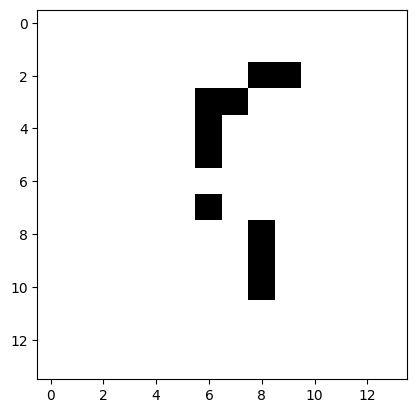

In [5]:
reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
plt.imshow(reconst[0], cmap='gray_r')

<img src="./assets/maskgit_2.4_example_output1.png" alt="nanoMaskGIT example output 1" width="500">

Let's now generate 10 random samples for all 10 classes. Most should look quite reasonable.

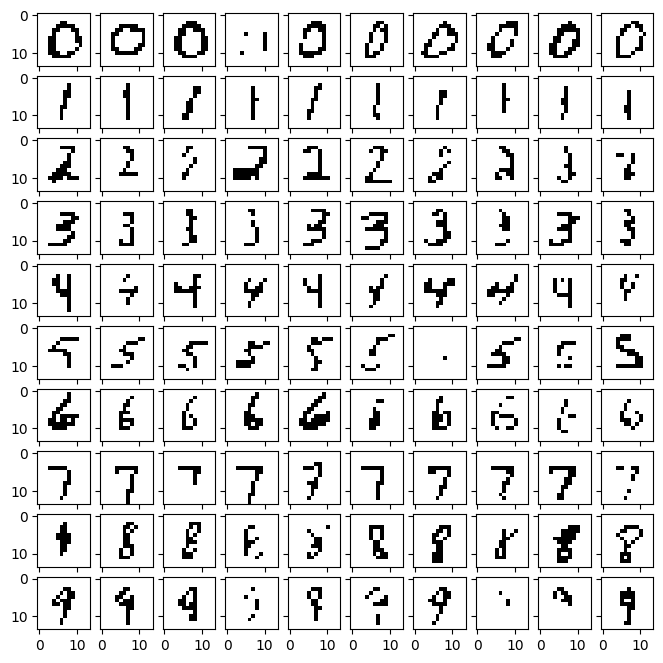

In [6]:
def generate_samples(model, num_steps=8, temp=1.0, top_p=0.0, top_k=0.0, n_samples=10):
    fig = plt.figure(figsize=(8., 8.))
    grid = ImageGrid(fig, 111, nrows_ncols=(10, n_samples), axes_pad=0.1)
    for label in range(10):
        for sample_idx in range(n_samples):
            grid_idx = label * n_samples + sample_idx
            
            seq = torch.zeros(50, dtype=torch.long, device=device)
            mask = torch.ones(50, dtype=torch.bool, device=device)
            seq[0] = label
            mask[0] = False
            output = model.generate(seq, mask, num_steps=num_steps, temp=temp, top_p=top_p, top_k=top_k, return_history=False)
            
            reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
            grid[grid_idx].imshow(reconst[0], cmap='Greys', vmin=0, vmax=1)
    plt.show()
    
generate_samples(model, num_steps=8, temp=0.7, top_p=0.9, top_k=0.0)

<img src="./assets/maskgit_2.4_example_output2.png" alt="nanoMaskGIT example output 1" width="1000">

### 2.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 2.5.1 Intermediate generation steps

`model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

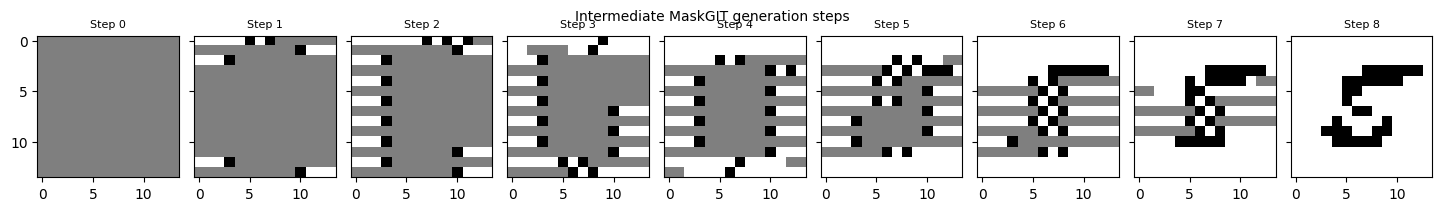

In [7]:
label = 5
seq = torch.zeros(50, dtype=torch.long, device=device)
mask = torch.ones(50, dtype=torch.bool, device=device)
seq[0] = label
mask[0] = False

seq_history, mask_history = model.generate(seq, mask, num_steps=8, temp=1.0, top_p=0.9, return_history=True)

n_steps = seq_history.shape[0]
fig = plt.figure(figsize=(2 * n_steps, 2))
grid = ImageGrid(fig, 111, nrows_ncols=(1, n_steps), axes_pad=0.15)
for i in range(n_steps):
    reconst = detokenize_MNIST(seq_history[i:i+1], patch_size=2, account_for_labels=True).cpu()
    img = reconst[0].clone()
    still_masked = mask_history[i, 1:]  # skip label token
    patches_masked = still_masked.view(7, 7)
    patch_mask_img = patches_masked.unsqueeze(-1).unsqueeze(-1).expand(7, 7, 2, 2).reshape(14, 14)
    img[patch_mask_img.bool()] = 0.5
    grid[i].imshow(img, cmap='gray_r', vmin=0, vmax=1)
    grid[i].set_title(f"Step {i}", fontsize=8)
plt.suptitle("Intermediate MaskGIT generation steps", fontsize=10)
plt.show()

**Observation:** The model progressively reveals tokens from a fully masked image. In the early steps, it unmasks the tokens it is most confident about, which tend to correspond to the coarse shape of the digit (e.g. background patches or obvious stroke locations). In later steps, it fills in the remaining ambiguous patches (edges, fine details). This confirms that the confidence-based unmasking strategy works as intended: easy tokens first, hard tokens last.

#### 2.5.2 Number of inference steps

With MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=8`, but how does generation with `k` = 1, 4, 8, 16, 32, 49 perform? What do you observe?

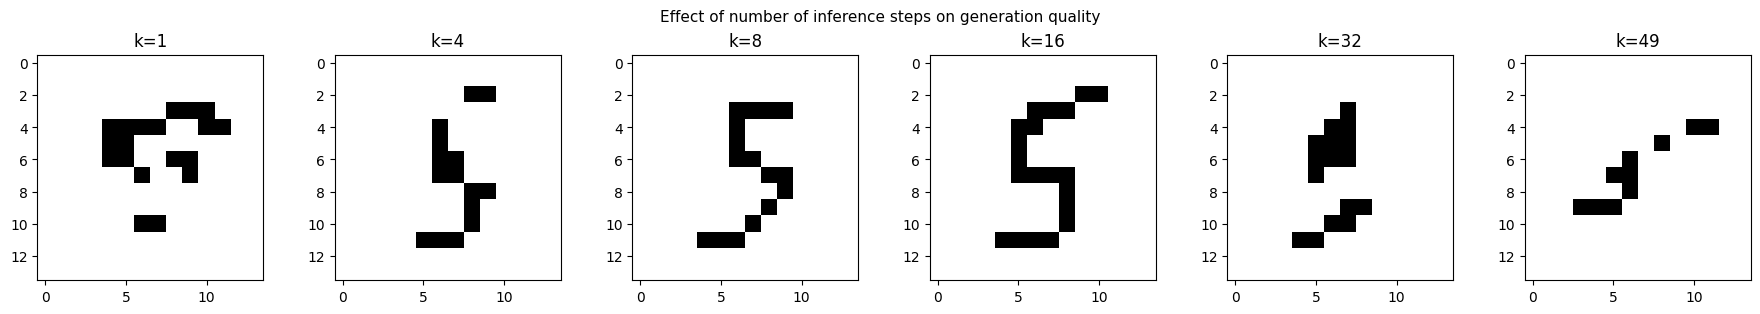

In [11]:
fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, k in zip(axes, [1, 4, 8, 16, 32, 49]):
    seq = torch.zeros(50, dtype=torch.long, device=device)
    mask = torch.ones(50, dtype=torch.bool, device=device)
    seq[0] = 5
    mask[0] = False
    output = model.generate(seq, mask, num_steps=k, temp=0.7, top_p=0.9, return_history=False)
    reconst = detokenize_MNIST(output, patch_size=2, account_for_labels=True).cpu()
    ax.imshow(reconst[0], cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(f"k={k}")
plt.suptitle("Effect of number of inference steps on generation quality", fontsize=11)
plt.tight_layout()
plt.show()

**Observation:** With k=1, all tokens are predicted at once and the results are noisy and malformed. Quality improves as we increase k, and the best results are obtained around k=8 where the digits look clean and well-formed. However, beyond k=8 the quality starts to degrade: at k=16 the digits are already less sharp, at k=32 they become clearly deteriorated, and at k=49 the images are mostly empty or unrecognizable. This is surprising since more steps should allow more refinement, but it seems that unmasking only a few tokens at a time actually hurts the model because each prediction is made with very little context. The sweet spot is around k=8.

---

## 3 Training nanoGPT on TinyStories

Masked generation is quite common for image generation, but has seen a recent resurgence for language models too (e.g. see [LLaDA](https://ml-gsai.github.io/LLaDA-demo/)). 
Let's run a little experiment and train a masked model on TinyStories, just as we did with nanoGPT.

### 3.1 Loading the tokenizer and helper functions

In [12]:
# Load the GPT-2 tokenizer
tokenizer = AutoTokenizer.from_pretrained("gpt2", trust_remote_code=True)

# Add padding, start-of-sequence, and end-of-sequence tokens
tokenizer.add_special_tokens({'pad_token': '[PAD]'})
tokenizer.add_special_tokens({
    'bos_token': '[SOS]',
    'eos_token': '[EOS]',
})
tokenizer._tokenizer.post_processor = TemplateProcessing(
    single="[SOS] $A [EOS]",
    special_tokens=[('[EOS]', tokenizer.eos_token_id), ('[SOS]', tokenizer.bos_token_id)],
)
tokenizer

GPT2TokenizerFast(name_or_path='gpt2', vocab_size=50257, model_max_length=1024, is_fast=True, padding_side='right', truncation_side='right', special_tokens={'bos_token': '[SOS]', 'eos_token': '[EOS]', 'unk_token': '<|endoftext|>', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=False, added_tokens_decoder={
	50256: AddedToken("<|endoftext|>", rstrip=False, lstrip=False, single_word=False, normalized=True, special=True),
	50257: AddedToken("[PAD]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50258: AddedToken("[SOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
	50259: AddedToken("[EOS]", rstrip=False, lstrip=False, single_word=False, normalized=False, special=True),
}
)

In [13]:
def token_ids_to_text(token_ids, text_tokenizer):
    """ Helper function to turn token sequences back to well-formatted text. """
    decoded = text_tokenizer.decode(token_ids)
    # Remove [SOS], [EOS], and [PAD] tokens along with surrounding horizontal whitespace only.
    decoded = re.sub(r'[ \t]*\[(SOS|EOS|PAD)\][ \t]*', ' ', decoded)
    # Collapse extra horizontal spaces in each line without touching newline characters.
    decoded = '\n'.join([re.sub(r'[ \t]+', ' ', line).strip() for line in decoded.splitlines()])
    return decoded

### 3.2 Training the model

We defined a training config for you in: `cfgs/nanoMaskGIT/tinystories_d8w512.yaml`. Please familiarize yourself with all parts.
Please don't forget to replace the Weights & Bias entity with your own.

On a 2xV100 node, you can start the training like:
```
OMP_NUM_THREADS=1 torchrun --nproc_per_node=2 run_training.py --config cfgs/nanoMaskGIT/tinystories_d8w512.yaml
```

This training should take over one hour. You should reach a final validation loss around 2.05, and your loss curves should look something like the following:

<img src="./assets/nanoMaskGIT_tinystories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.3 Show your loss curves (10 points)

Screenshot your loss curves and show them here. Add the image to the `assets` directory and change the path in the markdown. You will get 10 points for reasonable loss curves (similar to the sample loss curves above).

[Note] Your screenshot must clearly show your Weights & Biases (W&B) account (username/entity), usually visible in the top-right corner of the page.

<img src="./assets/NanoMaskGITTinyStories.png" alt="nanoMaskGIT TinyStories loss curves" width="1000">

### 3.4 Evaluating the model (10 points)

After you completed the training, load the model with the following cell. You may need to adjust the path if you changed it.
You will get 10 points if the outputs look reasonable (similar to the sample outputs provided below).

Hint: You can also load intermediate safetensors checkpoints to check the progress during training.

In [14]:
ckpt_path = './outputs/nanoMaskGIT/tinystories_d8w512/checkpoint-final.safetensors'
model = load_model_from_safetensors(ckpt_path, device=device)
print(f'{model.get_num_params() / 10**6}M parameters')

25.174528M parameters


Let's generate some random (unconditional) stories!

In [15]:
for _ in range(5):
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=128, temp=1.0, top_k=100, return_history=False)
    print(token_ids_to_text(output[0], text_tokenizer=tokenizer))
    print('\n' + '-'*50 + '\n')

L upon a time, was two little girls, Lisa and Peter. Lisa was a polite and old girl, Peter heard that Peter would never a moment before. As one day, Lisa to count, Lisa, Lisa took a peek! She had heard seen this bush in the bushes. Lisa ran to, but what the long before he saw: the was a special surprise. Peter

When Lisa counted and one, he heard opened the bush, a small sister,

"What, you ready to be with?" Lisa said with a gentle voice.
smiled. said, "I course you I have a you and!"

Peter happily hid happily and Lisa quickly up the surprise, when suddenly opened her wardrobe from and the. Lisa they both playing, looking at some birds the birds. were both smiled and smiled.

"Hello!" said Peter. "What are you doing in?"

LisaIt was a special and polite fairy appeared, and wanted to say about to say hello. Lisa said as soon, and he was excited.

Peter loved to spend the day making whisper froms friend. and one day, Lisa knew she had come back in. Every day Lisa and Peter stopped bein

<img src="./assets/maskgit_3.4_example_output.png" alt="nanoMaskGIT example output for 3.4" width="1000">

### 3.5 Open-ended questions (10 points each)

Please answer the following questions. You may use additional cells to demonstrate your answers if necessary.

#### 3.5.1 Intermediate generation steps

Similar as in 2.5.1, `model.generate` has an optional flag `return_history`. Show the intermediate generation steps. What do you observe?

In [25]:
seq = torch.zeros(256, dtype=torch.long, device=device)
mask = torch.ones(256, dtype=torch.bool, device=device)

seq_history, mask_history = model.generate(seq, mask, num_steps=16, temp=1.0, top_k=100, return_history=True)

steps_to_show = [0, 2, 4, 8, 12, 16]
for step in steps_to_show:
    tokens = seq_history[step]
    m = mask_history[step]
    words = []
    for i in range(len(tokens)):
        if m[i]:
            words.append('_')
        else:
            w = tokenizer.decode([tokens[i].item()])
            w = re.sub(r'\[(SOS|EOS|PAD)\]', '', w).strip()
            if w:
                words.append(w)
    text = ' '.join(words)
    n_unmasked = (~m).sum().item()
    print(f"Step {step} ({n_unmasked}/{256} tokens unmasked):")
    print(f"  {text}")
    print()

Step 0 (0/256 tokens unmasked):
  _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _

Step 2 (32/256 tokens unmasked):
  Once upon a time are there in a little town in , a bird little my small Lucy named was _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _ _

**Observation:** At step 0, everything is masked. At step 2, the first 32 tokens are revealed and they cluster at the beginning and end of the sequence: we see fragments like "Once upon a time", "little", "named", and at the very end "big", "his", ".". The model fills in the positions it's most confident about first, which tend to be common words and story-typical phrases. By step 4-8, more tokens fill in throughout the sequence but the text remains largely incoherent, with lots of repeated words ("bird", "little", "a") and broken grammar. We can also see that most of the early tokens are short, frequent words ("the", "a", "was", "her", "to"). By step 12, most of the sequence is filled but large gaps of `_` still remain in the middle. The revealed text has clear issues like excessive repetition of "bird" and fragmented sentences. At step 16 all tokens are unmasked and we get a complete text, but it reads poorly compared to autoregressive generation: the grammar is broken, words repeat a lot, and the story doesn't really make sense. This shows that filling tokens in a non-sequential order based on confidence makes it hard for the model to produce coherent text.

#### 3.5.2 Number of inference steps

Similar as in 2.5.1, with MaskGIT, we can freely choose the number of inference steps `k`. We default to `k=128`, but how does generation with `k` = 1, 16, 32, 64, 128, 256 perform? What do you observe?

In [20]:
for k in [1, 16, 32, 64, 128, 256]:
    seq = torch.zeros(256, dtype=torch.long, device=device)
    mask = torch.ones(256, dtype=torch.bool, device=device)
    output = model.generate(seq, mask, num_steps=k, temp=1.0, top_k=100, return_history=False)
    text = token_ids_to_text(output[0], text_tokenizer=tokenizer)
    print(f"=== k={k} ===")
    print(text[:300])
    print('\n' + '-'*50 + '\n')

=== k=1 ===
Once there, time twins was was three who for on with. Every liked and around for her Everymy. Every the
herOne a She One and He inOne ground to
It. She of
up he. the the
was so He decidedmy and
. The 's see and I,. help in the,TheThe " the it smiled and excited Tim away a it
,
". " the and " said" t

--------------------------------------------------

=== k=16 ===
Once upon a time there named called Amy. She lived a haircut attractive. to He

--------------------------------------------------

=== k=32 ===
L there a are there there was a happy of She

--------------------------------------------------

=== k=64 ===
Once upon a are there there were two friends, and one, the played friends.

--------------------------------------------------

=== k=128 ===
One upon a time, there was a little cat. The handle.

--------------------------------------------------

=== k=256 ===
Once upon a time, there was a little girl named Lily. She loved to bake cakes and cookies every day. On

**Observation:** With k=1, all tokens are predicted at once and the result is completely incoherent: just fragments of common words and punctuation with no structure. At k=16 and k=32, the text is still mostly broken, with repetitions and missing words, though we can start to see something resembling a sentence. At k=64, the beginning is still rough but the second half of the generation actually produces a fairly coherent story with proper sentences. This suggests that with enough refinement steps, the model can correct earlier mistakes. Overall the quality is much lower than autoregressive generation, especially for the beginning of the text where the model has less context to work with.

#### 3.5.3 Comparison to autoregressive generation

How would you compare these results to the ones you got from nanoGPT? What are some failure modes you observe? And what could be some benefits? Do you have any thoughs on how we can improve text generation with masked models, or should we just stick to autoregressive models?

**Observation:** Compared to nanoGPT, the text generated by MaskGIT is clearly worse. nanoGPT produces coherent stories with proper grammar, while MaskGIT outputs have obvious problems like repeated words ("girl girl"), broken sentences ("put on toy the high.."), and sometimes just random word fragments (especially with few steps).

The main failure modes come from the non-sequential generation order. Since the model does not predict tokens left-to-right, it can't build on what came before in the sentence. It fills in the tokens it's most confident about first (usually common words like "a", "the", "was"), and then tries to fill the gaps, which often leads to grammatical inconsistencies.

That said, MaskGIT has some advantages over autoregressive models:
- **Speed**: it can generate a full sequence in much fewer steps (e.g. 8-16 forward passes instead of 256 for autoregressive)
- **Flexibility**: since generation is not strictly left-to-right, we could in principle condition on any subset of tokens, which would be useful for tasks like text infilling or editing

To improve text generation with masked models, we could try using a better unmasking schedule (like cosine instead of constant) to reveal fewer tokens at the start and refine more carefully. We could also simply increase the number of steps to get closer to sequential quality.

But overall, for pure text generation, autoregressive models seem better suited since language naturally has a sequential structure. Masked models work much better for images, where there is no inherent left-to-right ordering and the spatial structure benefits from bidirectional context.

## 4 Further reading

Here is some further reading material should you want to dive deeper on masked modeling.

Masked image generation:
- [MaskGIT: Masked Generative Image Transformer](https://arxiv.org/abs/2202.04200)
- [Muse: Text-To-Image Generation via Masked Generative Transformers](https://arxiv.org/abs/2301.00704)
- [MAGE: MAsked Generative Encoder to Unify Representation Learning and Image Synthesis](https://arxiv.org/abs/2211.09117)
- [Randomized Autoregressive Visual Generation](https://arxiv.org/abs/2411.00776)
- [RandAR: Decoder-only Autoregressive Visual Generation in Random Orders](https://arxiv.org/abs/2412.01827)
- [Autoregressive Image Generation without Vector Quantization](https://arxiv.org/abs/2406.11838)
- [4M: Massively Multimodal Masked Modeling](https://arxiv.org/abs/2312.06647)

Masked text generation:
- [Exploring the Limits of Transfer Learning with a Unified Text-to-Text Transformer](https://arxiv.org/abs/1910.10683)
- [Structured Denoising Diffusion Models in Discrete State-Spaces](https://arxiv.org/abs/2107.03006)
- [Large Language Diffusion Models](https://arxiv.org/abs/2502.09992)

Masked pre-training:
- [BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding](https://arxiv.org/abs/1810.04805)
- [RoBERTa: A Robustly Optimized BERT Pretraining Approach](https://arxiv.org/abs/1907.11692)
- [ELECTRA: Pre-training Text Encoders as Discriminators Rather Than Generators](https://arxiv.org/abs/2003.10555)
- [Masked Autoencoders Are Scalable Vision Learners](https://arxiv.org/abs/2111.06377)
- [BEiT: BERT Pre-Training of Image Transformers](https://arxiv.org/abs/2106.08254)
- [BEiT v2: Masked Image Modeling with Vector-Quantized Visual Tokenizers](https://arxiv.org/abs/2208.06366)